In [1]:
# Cell 1: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

np.random.seed(42)

%matplotlib inline

print("Setup complete. You can start the experiment.")

Setup complete. You can start the experiment.


In [2]:
# Cell 2: Load Breast Cancer Dataset

cancer = load_breast_cancer(as_frame=True)

X = cancer.data
y = cancer.target

print("Dataset Shape:", X.shape)

print("\nTarget Class Counts:")
print(y.value_counts().sort_index())

print("\nTarget Names:")
print(cancer.target_names)

Dataset Shape: (569, 30)

Target Class Counts:
target
0    212
1    357
Name: count, dtype: int64

Target Names:
['malignant' 'benign']


In [3]:
# Cell 3: Display first 5 rows

print("First 5 rows of the dataset:")
display(X.head())

First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Cell 4: Dataset Information

print("Dataset Information:")
print(X.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoot

In [5]:
# Cell 5: Statistical Summary

display(X.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
# Cell 6: Check Missing Values

missing_values = X.isnull().sum()

print("Total Missing Values:", missing_values.sum())

if missing_values.sum() == 0:
    print("No missing values found.")
else:
    print("\nMissing values by feature:")
    print(missing_values[missing_values > 0])

Total Missing Values: 0
No missing values found.


In [7]:
# Cell 7: Standardize the Features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Dataset Shape:", X_scaled.shape)

print("\nMean of first 5 features:")
print(np.round(X_scaled.mean(axis=0)[:5], 3))

print("\nStandard deviation of first 5 features:")
print(np.round(X_scaled.std(axis=0)[:5], 3))

Scaled Dataset Shape: (569, 30)

Mean of first 5 features:
[-0.  0. -0. -0. -0.]

Standard deviation of first 5 features:
[1. 1. 1. 1. 1.]


In [8]:
# Cell 8: Apply PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Number of Features:", X_scaled.shape[1])
print("Reduced Number of Features:", X_pca.shape[1])

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca.explained_variance_ratio_.sum())

Original Number of Features: 30
Reduced Number of Features: 2

Explained Variance Ratio:
[0.44272026 0.18971182]

Total Explained Variance:
0.6324320765155944


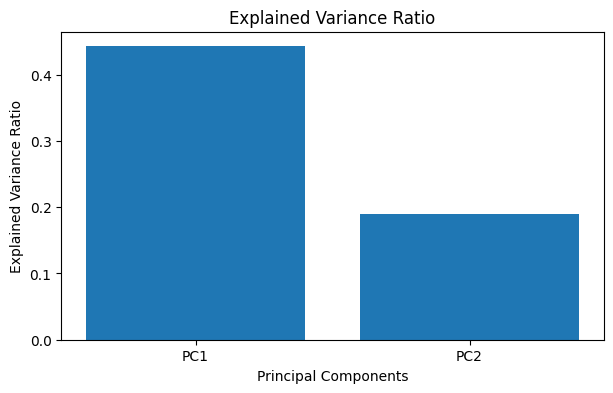

In [9]:
# Cell 9: Explained Variance Plot

plt.figure(figsize=(7, 4))

plt.bar(
    ["PC1", "PC2"],
    pca.explained_variance_ratio_
)

plt.title("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")

plt.show()

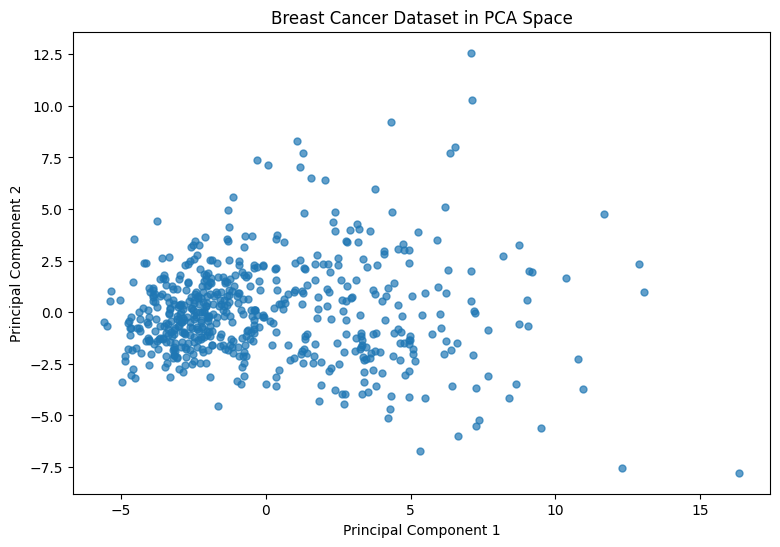

In [10]:
# Cell 10: PCA 2D Visualization

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=25,
    alpha=0.7
)

plt.title("Breast Cancer Dataset in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

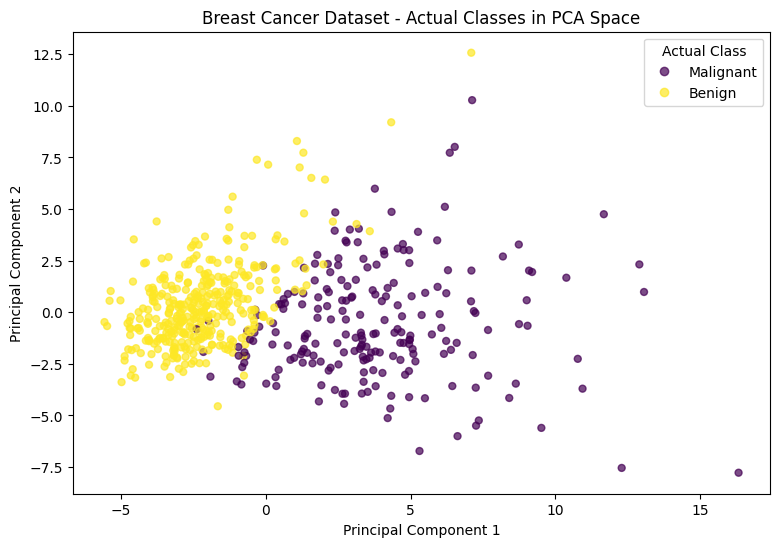

In [11]:
# Cell 11: PCA Visualization using Actual Labels

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    s=25,
    alpha=0.7
)

plt.title("Breast Cancer Dataset - Actual Classes in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=["Malignant", "Benign"],
    title="Actual Class"
)

plt.show()

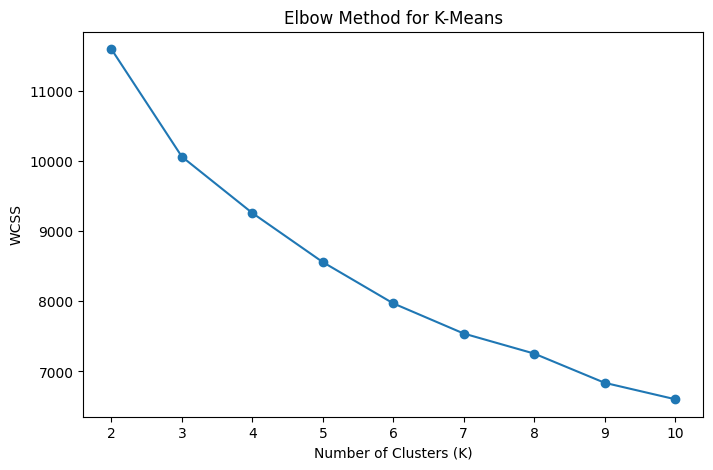

In [12]:
# Cell 12: Elbow Method

k_values = range(2, 11)

wcss = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    wcss,
    marker="o"
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

In [13]:
# Cell 13: K-Means Clustering

kmeans_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans_model.fit_predict(X_scaled)

print("K-Means clustering completed!")

print("\nNumber of clusters:")
print(kmeans_model.n_clusters)

K-Means clustering completed!

Number of clusters:
2


In [14]:
# Cell 14: K-Means Cluster Distribution

kmeans_counts = pd.Series(
    labels_kmeans
).value_counts().sort_index()

print("K-Means Cluster Distribution:")
print(kmeans_counts)

K-Means Cluster Distribution:
0    375
1    194
Name: count, dtype: int64


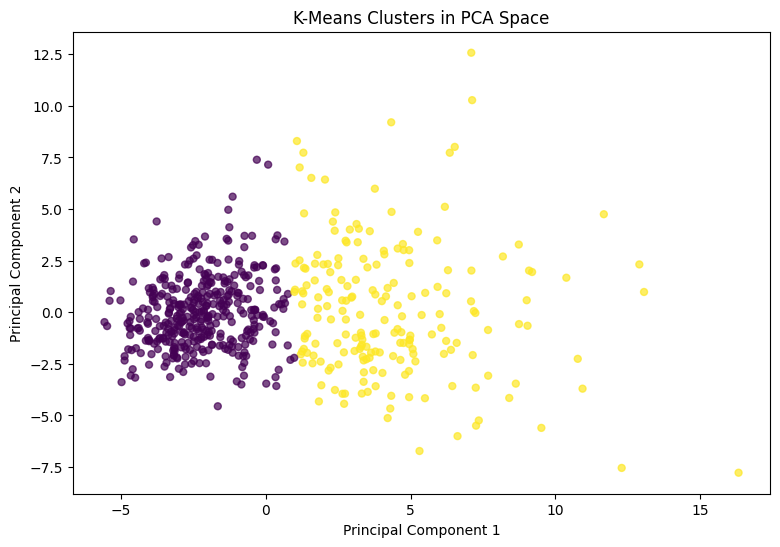

In [15]:
# Cell 15: K-Means Clusters in PCA Space

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_kmeans,
    s=25,
    alpha=0.7
)

plt.title("K-Means Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [16]:
# Cell 16: Evaluate K-Means

silhouette_kmeans = silhouette_score(
    X_scaled,
    labels_kmeans
)

db_kmeans = davies_bouldin_score(
    X_scaled,
    labels_kmeans
)

print("K-Means Evaluation")
print("----------------------------")
print(f"Silhouette Score     : {silhouette_kmeans:.4f}")
print(f"Davies-Bouldin Index : {db_kmeans:.4f}")

K-Means Evaluation
----------------------------
Silhouette Score     : 0.3434
Davies-Bouldin Index : 1.3205


In [17]:
# Cell 17: Select Sample for Hierarchical Clustering

sample_size = 300

np.random.seed(42)

sample_indices = np.random.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

print("Hierarchical Clustering Sample Shape:")
print(X_sample.shape)

Hierarchical Clustering Sample Shape:
(300, 30)


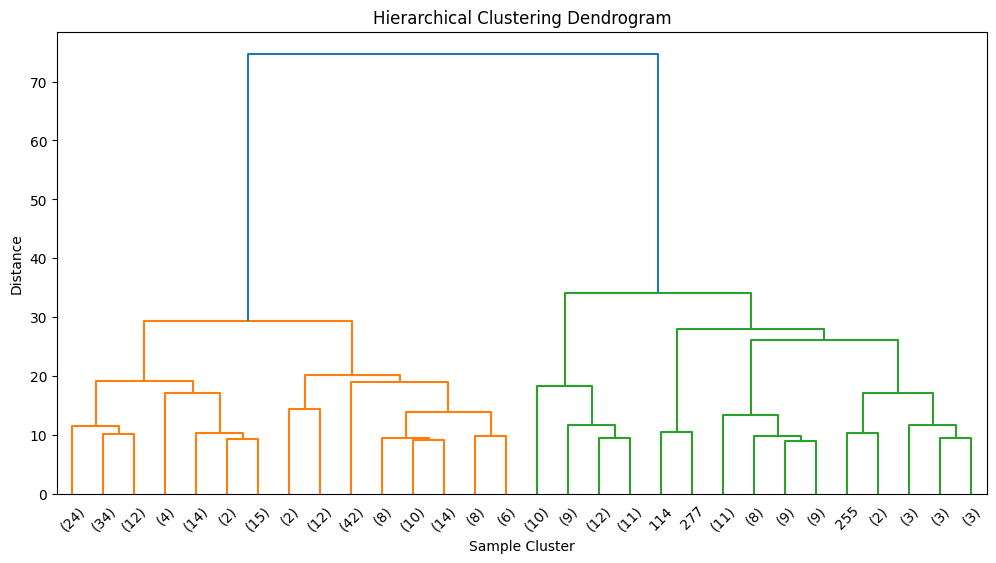

In [18]:
# Cell 18: Hierarchical Clustering Dendrogram

merge_matrix = linkage(
    X_sample,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    merge_matrix,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Cluster")
plt.ylabel("Distance")

plt.show()

In [19]:
# Cell 19: Agglomerative Hierarchical Clustering

hier_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

labels_hier = hier_model.fit_predict(
    X_sample
)

print("Hierarchical Clustering completed!")
print("Number of clusters:", hier_model.n_clusters)

Hierarchical Clustering completed!
Number of clusters: 2


In [20]:
# Cell 20: Evaluate Hierarchical Clustering

silhouette_hier = silhouette_score(
    X_sample,
    labels_hier
)

db_hier = davies_bouldin_score(
    X_sample,
    labels_hier
)

print("Hierarchical Clustering Evaluation")
print("------------------------------------")
print(f"Silhouette Score     : {silhouette_hier:.4f}")
print(f"Davies-Bouldin Index : {db_hier:.4f}")

Hierarchical Clustering Evaluation
------------------------------------
Silhouette Score     : 0.3483
Davies-Bouldin Index : 1.2909


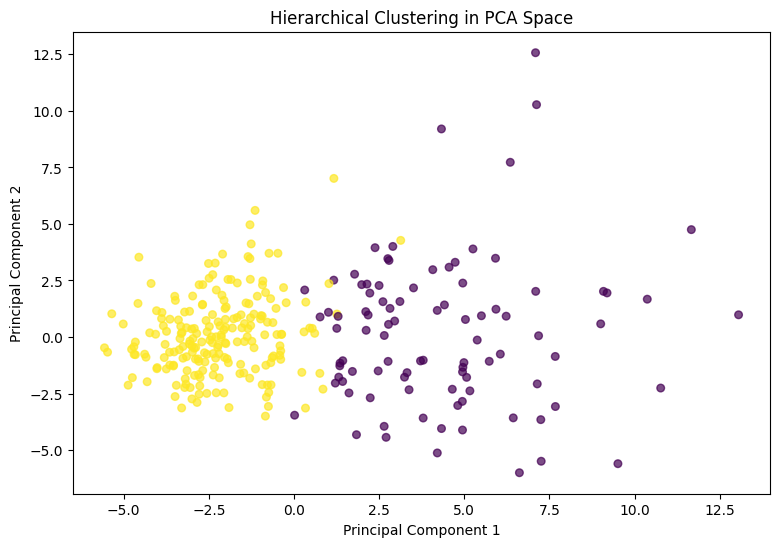

In [21]:
# Cell 21: Hierarchical Clustering in PCA Space

X_sample_pca = pca.transform(X_sample)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_sample_pca[:, 0],
    X_sample_pca[:, 1],
    c=labels_hier,
    s=30,
    alpha=0.7
)

plt.title("Hierarchical Clustering in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

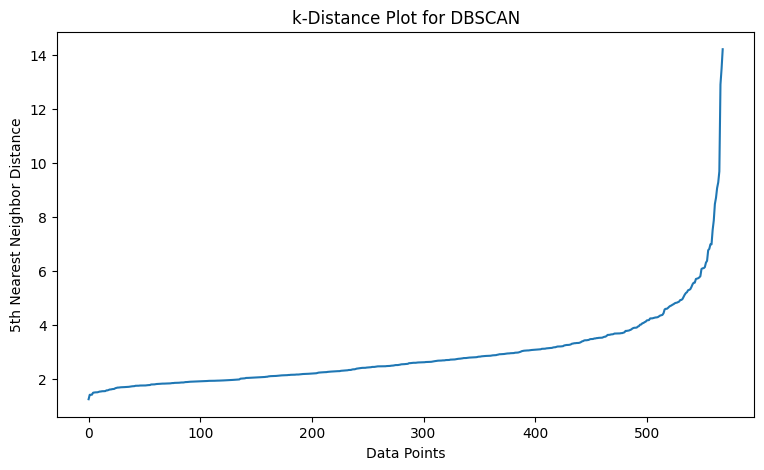

In [22]:
# Cell 22: k-Distance Plot

k = 5

neighbors = NearestNeighbors(
    n_neighbors=k
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(
    X_scaled
)

k_distances = np.sort(
    distances[:, k - 1]
)

plt.figure(figsize=(9, 5))

plt.plot(k_distances)

plt.title("k-Distance Plot for DBSCAN")
plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")

plt.show()

In [23]:
# Cell 23: DBSCAN Clustering

dbscan_model = DBSCAN(
    eps=2.0,
    min_samples=5
)

labels_dbscan = dbscan_model.fit_predict(
    X_scaled
)

print("DBSCAN clustering completed!")

DBSCAN clustering completed!


In [24]:
# Cell 24: DBSCAN Cluster Information

n_clusters_dbscan = len(
    set(labels_dbscan)
) - (1 if -1 in labels_dbscan else 0)

n_noise = int(
    (labels_dbscan == -1).sum()
)

print("DBSCAN Information")
print("----------------------------")
print("Epsilon (eps)     :", dbscan_model.eps)
print("Min Samples       :", dbscan_model.min_samples)
print("Clusters Found    :", n_clusters_dbscan)
print("Noise Points      :", n_noise)

DBSCAN Information
----------------------------
Epsilon (eps)     : 2.0
Min Samples       : 5
Clusters Found    : 4
Noise Points      : 371


In [25]:
# Cell 25: Evaluate DBSCAN

valid_mask = labels_dbscan != -1

if (
    n_clusters_dbscan > 1
    and valid_mask.sum() > n_clusters_dbscan
):

    silhouette_dbscan = silhouette_score(
        X_scaled[valid_mask],
        labels_dbscan[valid_mask]
    )

    db_dbscan = davies_bouldin_score(
        X_scaled[valid_mask],
        labels_dbscan[valid_mask]
    )

    print("DBSCAN Evaluation")
    print("----------------------------")
    print(f"Silhouette Score     : {silhouette_dbscan:.4f}")
    print(f"Davies-Bouldin Index : {db_dbscan:.4f}")

else:

    silhouette_dbscan = np.nan
    db_dbscan = np.nan

    print(
        "DBSCAN did not produce enough valid clusters "
        "for evaluation."
    )

DBSCAN Evaluation
----------------------------
Silhouette Score     : 0.0978
Davies-Bouldin Index : 1.0211


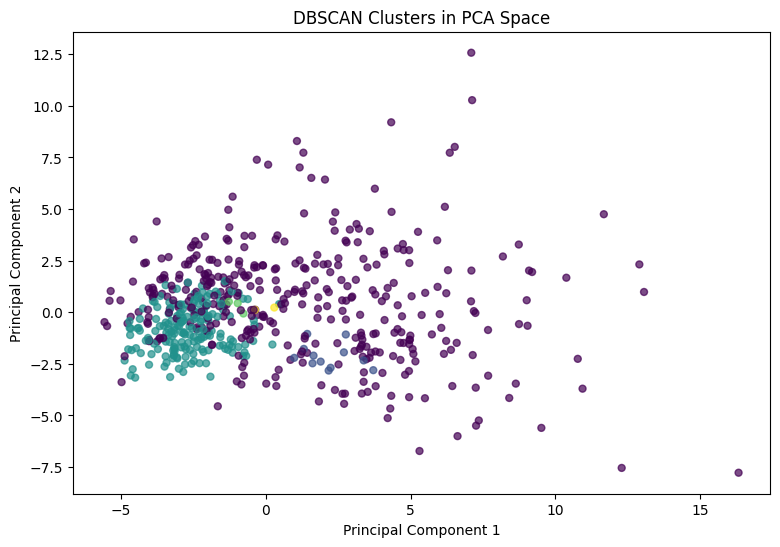

In [26]:
# Cell 26: DBSCAN Clusters in PCA Space

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_dbscan,
    s=25,
    alpha=0.7
)

plt.title("DBSCAN Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [27]:
# Cell 27: Compare Clustering Algorithms

comparison = [
    [
        "K-Means",
        kmeans_model.n_clusters,
        silhouette_kmeans,
        db_kmeans
    ],
    [
        "Hierarchical",
        hier_model.n_clusters,
        silhouette_hier,
        db_hier
    ],
    [
        "DBSCAN",
        n_clusters_dbscan,
        silhouette_dbscan,
        db_dbscan
    ]
]

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Algorithm",
        "Number of Clusters",
        "Silhouette Score",
        "Davies-Bouldin Index"
    ]
)

display(comparison_df)

,Algorithm,Number of Clusters,Silhouette Score,Davies-Bouldin Index
0,K-Means,2,0.343382,1.320510
1,Hierarchical,2,0.348272,1.290941
2,DBSCAN,4,0.097753,1.021067


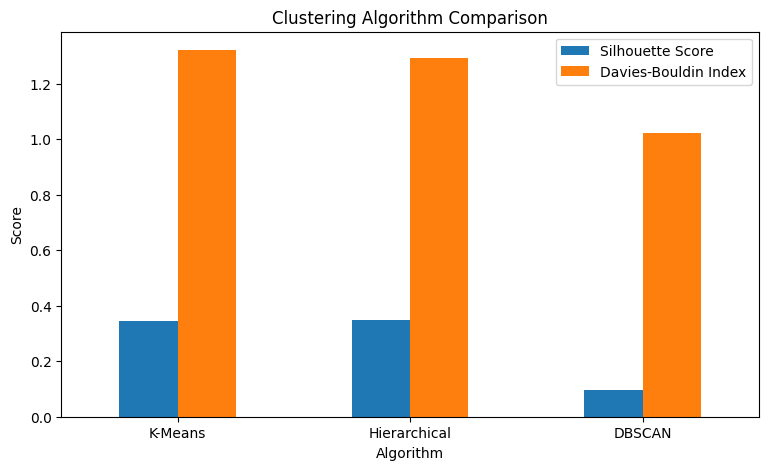

In [28]:
# Cell 28: Algorithm Comparison

comparison_df.set_index(
    "Algorithm"
)[
    ["Silhouette Score", "Davies-Bouldin Index"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Clustering Algorithm Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

In [29]:
# Cell 29: Compare Actual Classes and K-Means Clusters

comparison_labels = pd.crosstab(
    y,
    labels_kmeans
)

comparison_labels.index = [
    "Malignant",
    "Benign"
]

comparison_labels.columns = [
    "Cluster 0",
    "Cluster 1"
]

print("Actual Class vs K-Means Cluster:")
display(comparison_labels)

Actual Class vs K-Means Cluster:


,Cluster 0,Cluster 1
Malignant,36,176
Benign,339,18


In [30]:
# Cell 30: Final Experiment Summary

print("=" * 55)
print("       EXPERIMENT 05 - FINAL SUMMARY")
print("=" * 55)

print("\nDataset:")
print("Breast Cancer Wisconsin Dataset")

print("\nDataset Shape:")
print(X.shape)

print("\nNumber of Features:")
print(X.shape[1])

print("\nPCA:")
print("Number of Components:", pca.n_components_)
print(
    "Total Explained Variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

print("\nK-Means:")
print("Clusters:", kmeans_model.n_clusters)
print(
    "Silhouette Score:",
    round(silhouette_kmeans, 4)
)
print(
    "Davies-Bouldin Index:",
    round(db_kmeans, 4)
)

print("\nHierarchical Clustering:")
print("Clusters:", hier_model.n_clusters)
print(
    "Silhouette Score:",
    round(silhouette_hier, 4)
)
print(
    "Davies-Bouldin Index:",
    round(db_hier, 4)
)

print("\nDBSCAN:")
print("Clusters:", n_clusters_dbscan)
print("Noise Points:", n_noise)

if not np.isnan(silhouette_dbscan):

    print(
        "Silhouette Score:",
        round(silhouette_dbscan, 4)
    )

    print(
        "Davies-Bouldin Index:",
        round(db_dbscan, 4)
    )

print("\n" + "=" * 55)
print("Experiment completed successfully!")
print("=" * 55)

       EXPERIMENT 05 - FINAL SUMMARY

Dataset:
Breast Cancer Wisconsin Dataset

Dataset Shape:
(569, 30)

Number of Features:
30

PCA:
Number of Components: 2
Total Explained Variance: 0.6324

K-Means:
Clusters: 2
Silhouette Score: 0.3434
Davies-Bouldin Index: 1.3205

Hierarchical Clustering:
Clusters: 2
Silhouette Score: 0.3483
Davies-Bouldin Index: 1.2909

DBSCAN:
Clusters: 4
Noise Points: 371
Silhouette Score: 0.0978
Davies-Bouldin Index: 1.0211

Experiment completed successfully!
